# Titanic Dataset - TensorFlow/Keras Neural Network Classification

This notebook implements deep learning models using TensorFlow/Keras for Titanic survival classification.

## Objectives:
1. Load preprocessed data
2. Build neural network architectures with Keras
3. Train models:
   - Simple Neural Network
   - Deep Neural Network
4. Implement callbacks (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau)
5. Evaluate model performance
6. Visualize training progress
7. Compare with PyTorch and traditional ML models
8. Save trained models

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Input, Add, Activation
)

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Check TensorFlow version and GPU availability
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
if len(tf.config.list_physical_devices('GPU')) > 0:
    print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.16.1
GPU available: False


## 1. Load and Prepare Data

In [2]:
# Load preprocessed data
data_path = Path('../data/processed/titanic_processed.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (891, 29)

Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'HasCabin', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teenager', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']

First few rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,...,AgeGroup_Adult,AgeGroup_Senior,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,0,22.0,1,0,7.2500,2,0,3.62500,...,0,0,0,0,0,0,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,2,0,35.64165,...,1,0,0,1,0,0,0,0,0,0
2,1,3,1,26.0,0,0,7.9250,1,1,7.92500,...,0,0,0,0,0,0,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,2,0,26.55000,...,0,0,0,1,0,0,0,0,0,0
4,0,3,0,35.0,0,0,8.0500,1,1,8.05000,...,0,0,0,0,0,0,0,0,0,1


In [3]:
# Separate features and target
X = df.drop('Survived', axis=1).values
y = df['Survived'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Class {label}: {count} ({count/len(y)*100:.2f}%)")

Features shape: (891, 28)
Target shape: (891,)
Number of features: 28

Class distribution:
Class 0: 549 (61.62%)
Class 1: 342 (38.38%)


In [4]:
# Split data into train, validation, and test sets
# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Second split: 75% train, 25% validation (of the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set survival rate: {y_train.mean():.2%}")
print(f"Validation set survival rate: {y_val.mean():.2%}")
print(f"Test set survival rate: {y_test.mean():.2%}")

Training set size: 534 (59.9%)
Validation set size: 178 (20.0%)
Test set size: 179 (20.1%)

Training set survival rate: 38.39%
Validation set survival rate: 38.20%
Test set survival rate: 38.55%


In [5]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print(f"\nScaled features statistics (training set):")
print(f"Mean: {X_train_scaled.mean(axis=0)[:5]}...")  # Show first 5
print(f"Std: {X_train_scaled.std(axis=0)[:5]}...")  # Show first 5

Feature scaling completed.

Scaled features statistics (training set):
Mean: [ 1.62375315e-16  7.11041712e-17  7.59639958e-17  1.14348813e-17
 -2.61962736e-17]...
Std: [1. 1. 1. 1. 1.]...


## 2. Define Evaluation Functions

In [6]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a Keras model and return metrics."""
    # Make predictions
    y_pred_proba = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }
    
    return results, y_pred, y_pred_proba


def plot_training_history(history, model_name):
    """Plot training and validation metrics."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Training History - Loss ({model_name})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Training History - Accuracy ({model_name})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Did not survive', 'Survived'],
                yticklabels=['Did not survive', 'Survived'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_true, y_pred_proba, model_name):
    """Plot ROC curve."""
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Evaluation functions defined.")

Evaluation functions defined.


## 3. Build Neural Network Models

### 3.1 Simple Neural Network

In [7]:
def create_simple_nn(input_dim, hidden_size1=64, hidden_size2=32, dropout_rate=0.3, learning_rate=0.001):
    """
    Create a simple neural network with 2 hidden layers.
    """
    model = Sequential([
        # Input layer
        Input(shape=(input_dim,)),
        
        # First hidden layer
        Dense(hidden_size1, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(dropout_rate),
        
        # Second hidden layer
        Dense(hidden_size2, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(dropout_rate),
        
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


# Create and display model
input_dim = X_train.shape[1]
simple_model = create_simple_nn(input_dim)

print("="*80)
print("SIMPLE NEURAL NETWORK ARCHITECTURE")
print("="*80)
simple_model.summary()

# Count parameters
trainable_params = simple_model.count_params()
print(f"\nTotal trainable parameters: {trainable_params:,}")

SIMPLE NEURAL NETWORK ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,161 (16.25 KB)

 Non-trainable params: 192 (768.00 B)


Total trainable parameters: 4,353


### 3.2 Deep Neural Network

In [8]:
def create_deep_nn(input_dim, hidden_sizes=[128, 64, 32, 16], dropout_rate=0.4, learning_rate=0.001):
    """
    Create a deep neural network with 4 hidden layers.
    """
    model = Sequential([
        # Input layer
        Input(shape=(input_dim,)),
        
        # First hidden layer
        Dense(hidden_sizes[0], kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(dropout_rate),
        
        # Second hidden layer
        Dense(hidden_sizes[1], kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(dropout_rate),
        
        # Third hidden layer
        Dense(hidden_sizes[2], kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(dropout_rate),
        
        # Fourth hidden layer
        Dense(hidden_sizes[3], kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(dropout_rate),
        
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


# Create and display model
deep_model = create_deep_nn(input_dim)

print("="*80)
print("DEEP NEURAL NETWORK ARCHITECTURE")
print("="*80)
deep_model.summary()

# Count parameters
trainable_params = deep_model.count_params()
print(f"\nTotal trainable parameters: {trainable_params:,}")

DEEP NEURAL NETWORK ARCHITECTURE


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,553 (60.75 KB)

 Trainable params: 15,073 (58.88 KB)

 Non-trainable params: 480 (1.88 KB)


Total trainable parameters: 15,553


## 4. Define Training Callbacks

In [14]:
def get_callbacks(model_name, patience=15):
    """
    Create callbacks for model training.
    """
    # Create checkpoint directory
    checkpoint_dir = Path('../models/tensorflow/checkpoints')
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    
    callback_list = [
        # Early stopping
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Model checkpoint
        callbacks.ModelCheckpoint(
            filepath=str(checkpoint_dir / f'{model_name}_best.keras'),
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        ),
        
        # Reduce learning rate on plateau
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    return callback_list

print("Callback functions defined.")

Callback functions defined.


## 5. Train Models

### 5.1 Train Simple Neural Network

In [15]:
print("="*80)
print("TRAINING SIMPLE NEURAL NETWORK")
print("="*80)

# Get callbacks
simple_callbacks = get_callbacks('simple_nn', patience=15)

# Train model
simple_history = simple_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=simple_callbacks,
    verbose=1
)

print("\nTraining completed!")

TRAINING SIMPLE NEURAL NETWORK
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5854 - loss: 0.8175 - val_accuracy: 0.6236 - val_loss: 0.8167 - learning_rate: 0.0010
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7243 - loss: 0.6804 - val_accuracy: 0.7079 - val_loss: 0.7275 - learning_rate: 0.0010
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7739 - loss: 0.6216 - val_accuracy: 0.7640 - val_loss: 0.6627 - learning_rate: 0.0010
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7736 - loss: 0.5716 - val_accuracy: 0.7753 - val_loss: 0.6212 - learning_rate: 0.0010
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7721 - loss: 0.5683 - val_accuracy: 0.7978 - val_loss: 0.5983 - learning_rate: 0.0010
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7886 - loss: 0.5340 - val_accuracy: 0.8090 - val_loss: 0.5812 - learning_rate: 0.0010
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

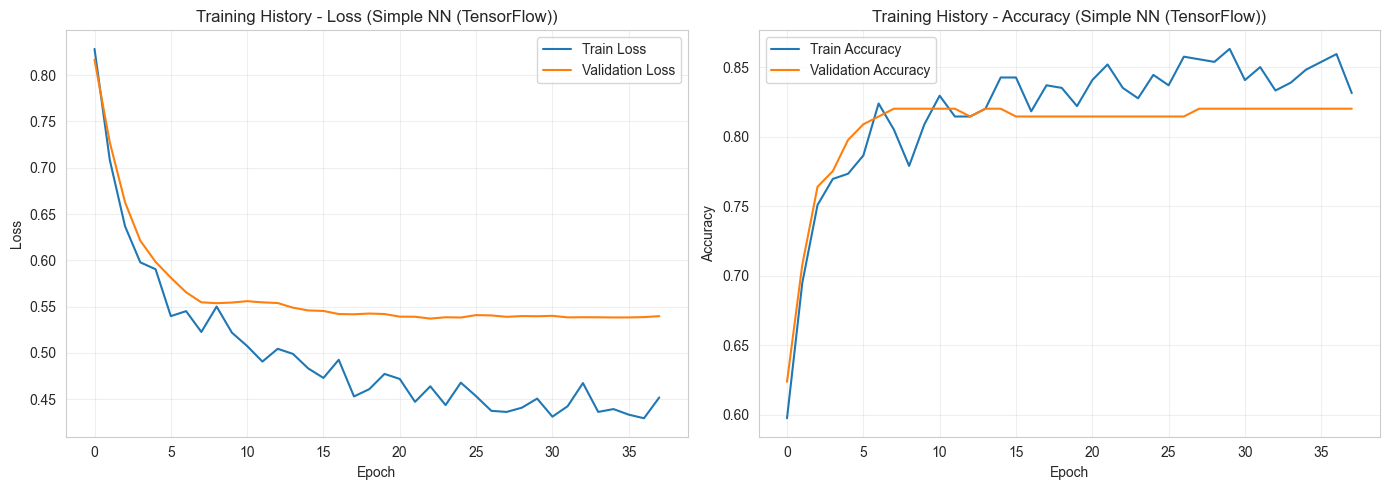

In [16]:
# Plot training history
plot_training_history(simple_history, 'Simple NN (TensorFlow)')

In [17]:
# Evaluate on test set
simple_results, simple_pred, simple_pred_proba = evaluate_model(
    simple_model, X_test_scaled, y_test, 'Simple NN (TensorFlow)'
)

print("="*80)
print("SIMPLE NN - TEST SET RESULTS")
print("="*80)
for key, value in simple_results.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, simple_pred,
                          target_names=['Did not survive', 'Survived']))

SIMPLE NN - TEST SET RESULTS
Accuracy: 0.7765
Precision: 0.7231
Recall: 0.6812
F1 Score: 0.7015
ROC AUC: 0.8295

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.81      0.84      0.82       110
       Survived       0.72      0.68      0.70        69

       accuracy                           0.78       179
      macro avg       0.77      0.76      0.76       179
   weighted avg       0.77      0.78      0.78       179



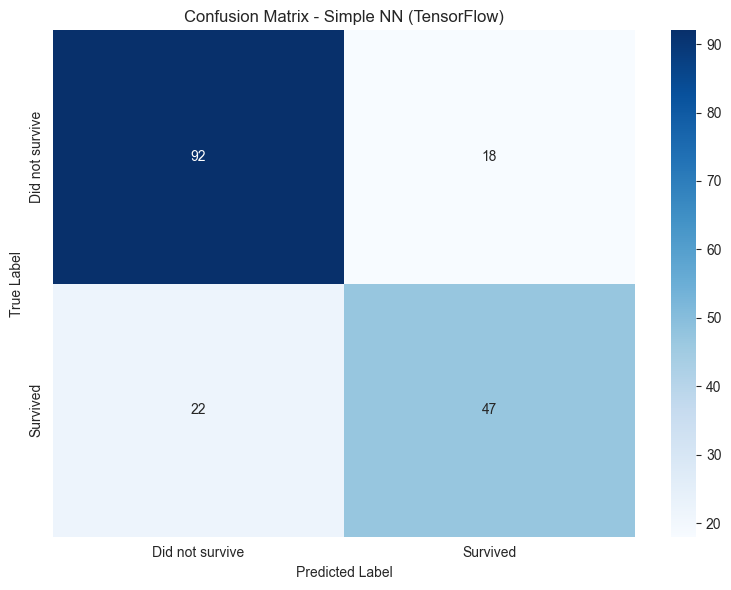

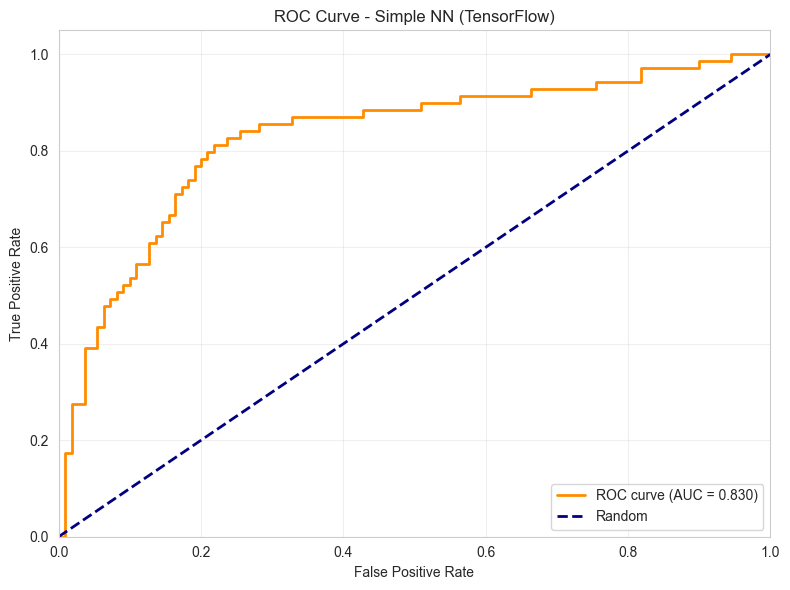

In [18]:
# Visualizations
plot_confusion_matrix(y_test, simple_pred, 'Simple NN (TensorFlow)')
plot_roc_curve(y_test, simple_pred_proba, 'Simple NN (TensorFlow)')

### 5.2 Train Deep Neural Network

In [19]:
print("="*80)
print("TRAINING DEEP NEURAL NETWORK")
print("="*80)

# Get callbacks
deep_callbacks = get_callbacks('deep_nn', patience=15)

# Train model
deep_history = deep_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=deep_callbacks,
    verbose=1
)

print("\nTraining completed!")

TRAINING DEEP NEURAL NETWORK
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5192 - loss: 0.9647 - val_accuracy: 0.5225 - val_loss: 0.8773 - learning_rate: 0.0010
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6083 - loss: 0.8736 - val_accuracy: 0.7022 - val_loss: 0.8492 - learning_rate: 0.0010
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6255 - loss: 0.8771 - val_accuracy: 0.7303 - val_loss: 0.8239 - learning_rate: 0.0010
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6421 - loss: 0.8549 - val_accuracy: 0.7472 - val_loss: 0.8015 - learning_rate: 0.0010
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6796 - loss: 0.7874 - val_accuracy: 0.7584 - val_loss: 0.7755 - learning_rate: 0.0010
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6759 - loss: 0.8109 - val_accuracy: 0.7809 - val_loss: 0.7545 - learning_rate: 0.0010
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0

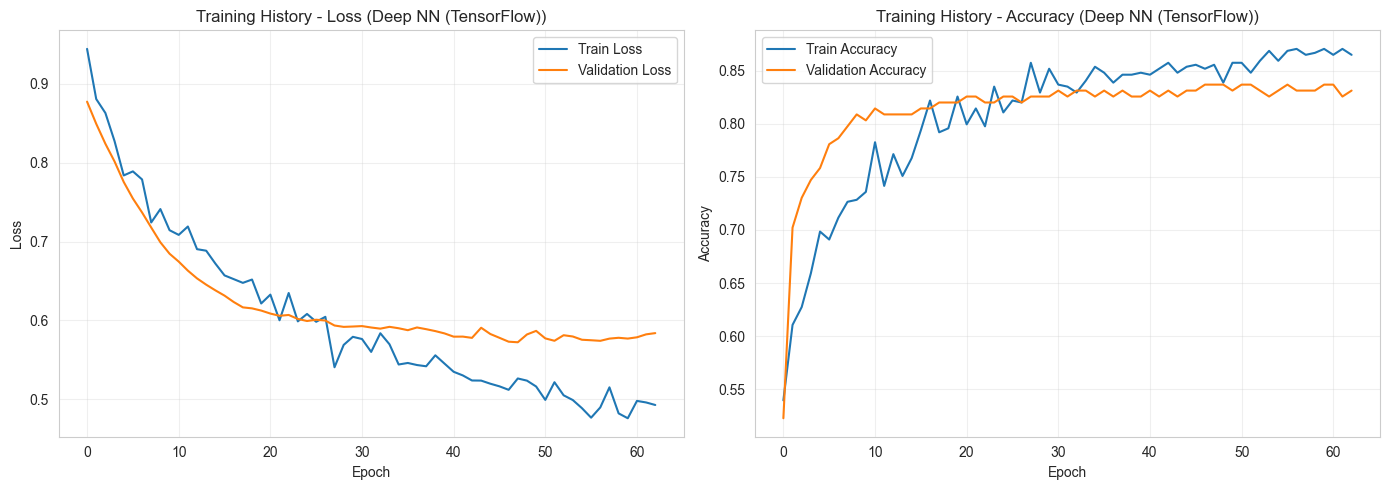

In [20]:
# Plot training history
plot_training_history(deep_history, 'Deep NN (TensorFlow)')

In [21]:
# Evaluate on test set
deep_results, deep_pred, deep_pred_proba = evaluate_model(
    deep_model, X_test_scaled, y_test, 'Deep NN (TensorFlow)'
)

print("="*80)
print("DEEP NN - TEST SET RESULTS")
print("="*80)
for key, value in deep_results.items():
    if key != 'Model':
        print(f"{key}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, deep_pred,
                          target_names=['Did not survive', 'Survived']))

DEEP NN - TEST SET RESULTS
Accuracy: 0.8101
Precision: 0.8182
Recall: 0.6522
F1 Score: 0.7258
ROC AUC: 0.8231

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.81      0.91      0.85       110
       Survived       0.82      0.65      0.73        69

       accuracy                           0.81       179
      macro avg       0.81      0.78      0.79       179
   weighted avg       0.81      0.81      0.81       179



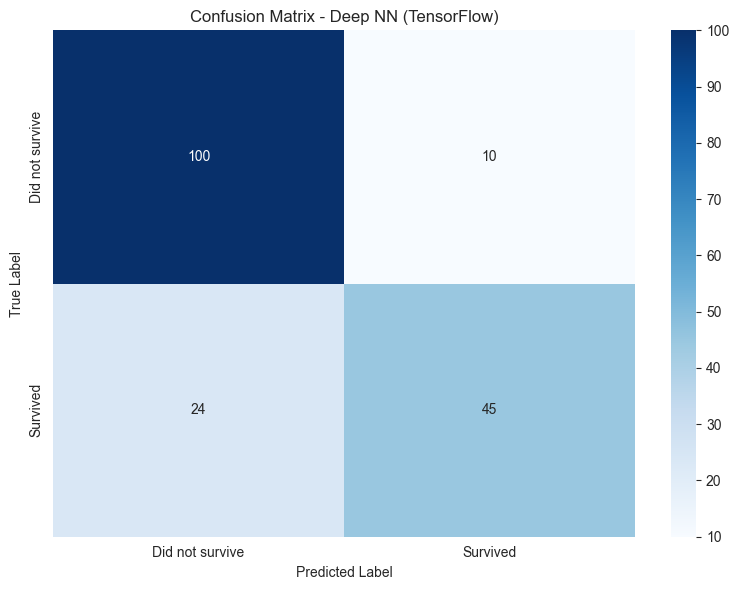

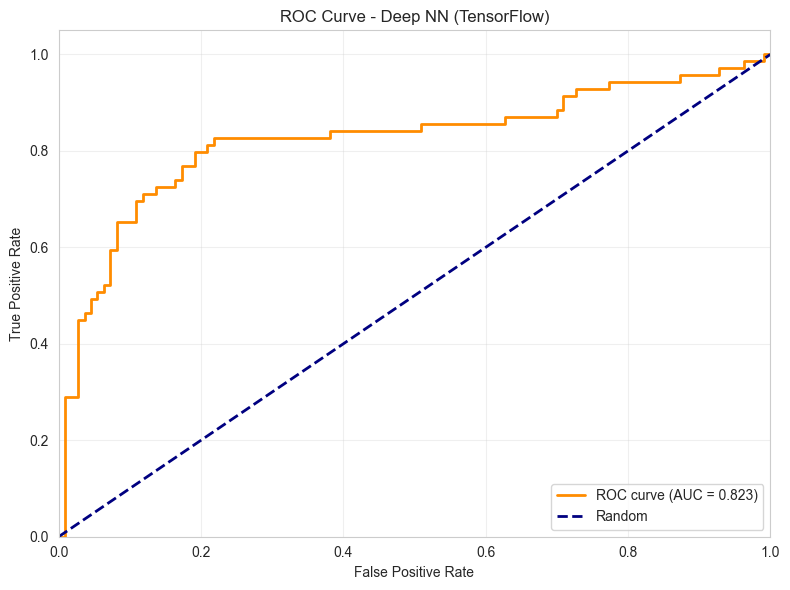

In [22]:
# Visualizations
plot_confusion_matrix(y_test, deep_pred, 'Deep NN (TensorFlow)')
plot_roc_curve(y_test, deep_pred_proba, 'Deep NN (TensorFlow)')

## 6. Compare TensorFlow Models

In [23]:
# Compile TensorFlow results
tf_comparison = pd.DataFrame([simple_results, deep_results]).set_index('Model')

print("="*80)
print("TENSORFLOW MODELS COMPARISON")
print("="*80)
print(tf_comparison.round(4))

TENSORFLOW MODELS COMPARISON
                        Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                                 
Simple NN (TensorFlow)    0.7765     0.7231  0.6812    0.7015   0.8295
Deep NN (TensorFlow)      0.8101     0.8182  0.6522    0.7258   0.8231


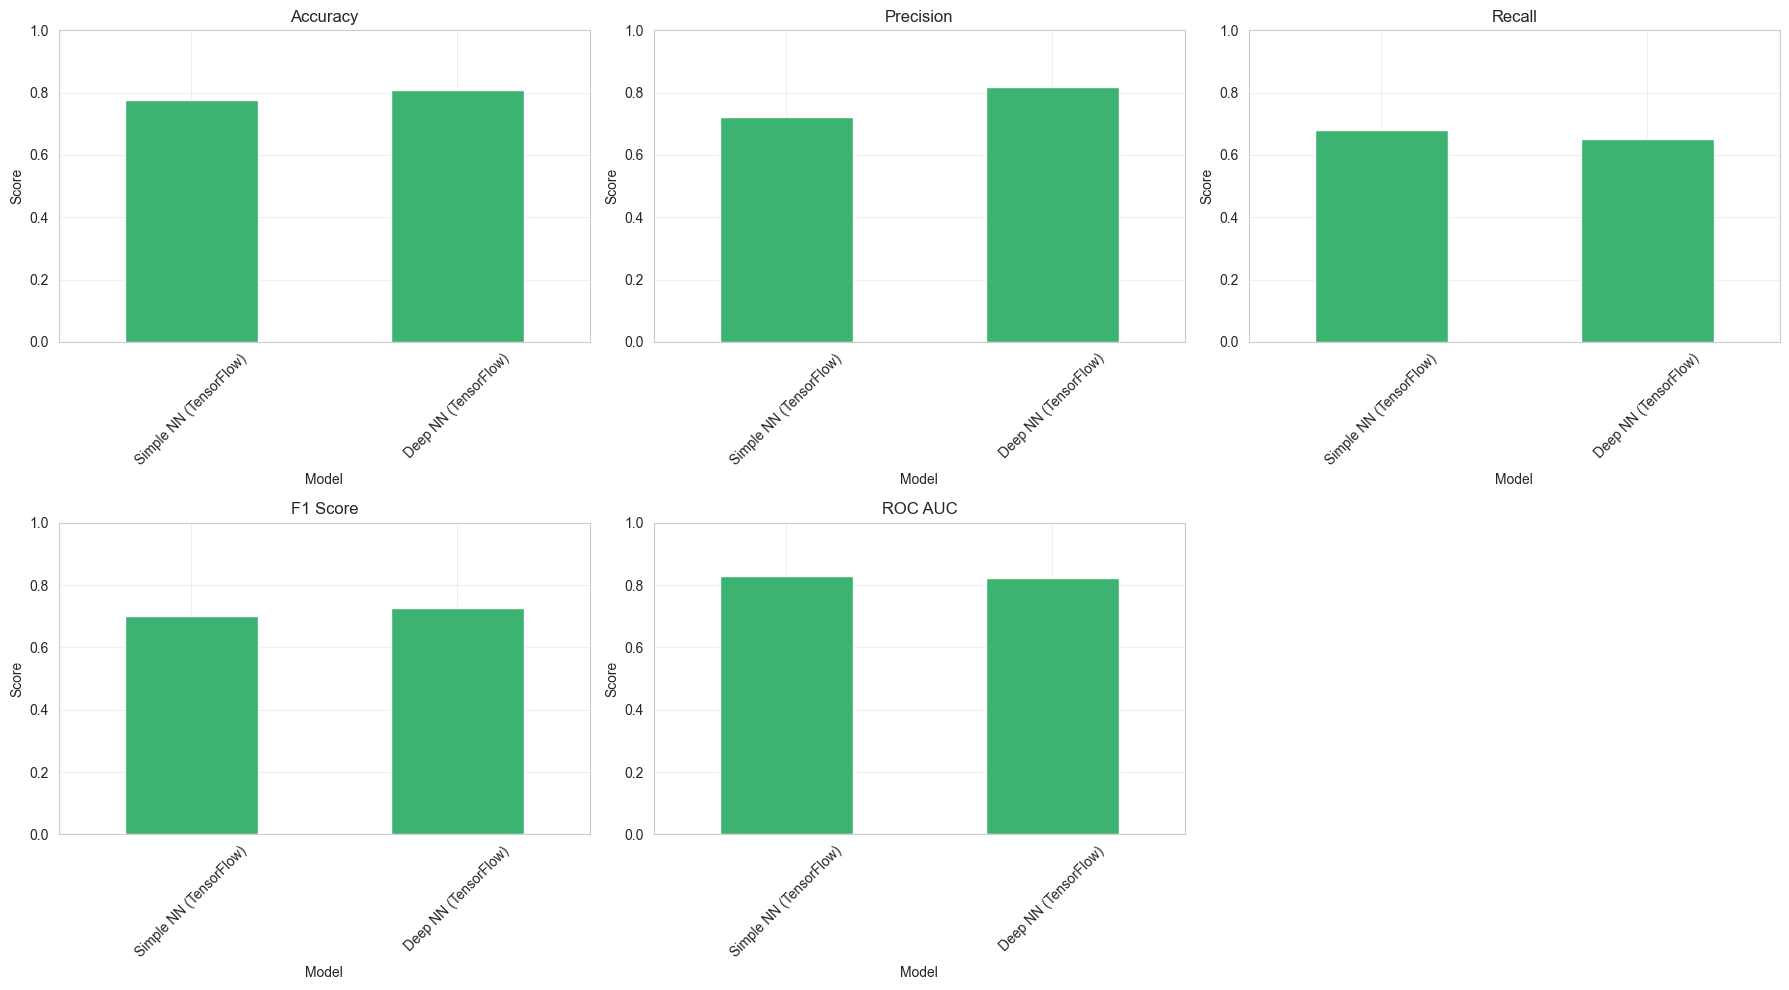

In [24]:
# Visualize comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    tf_comparison[metric].plot(kind='bar', ax=ax, color='mediumseagreen')
    ax.set_title(metric)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

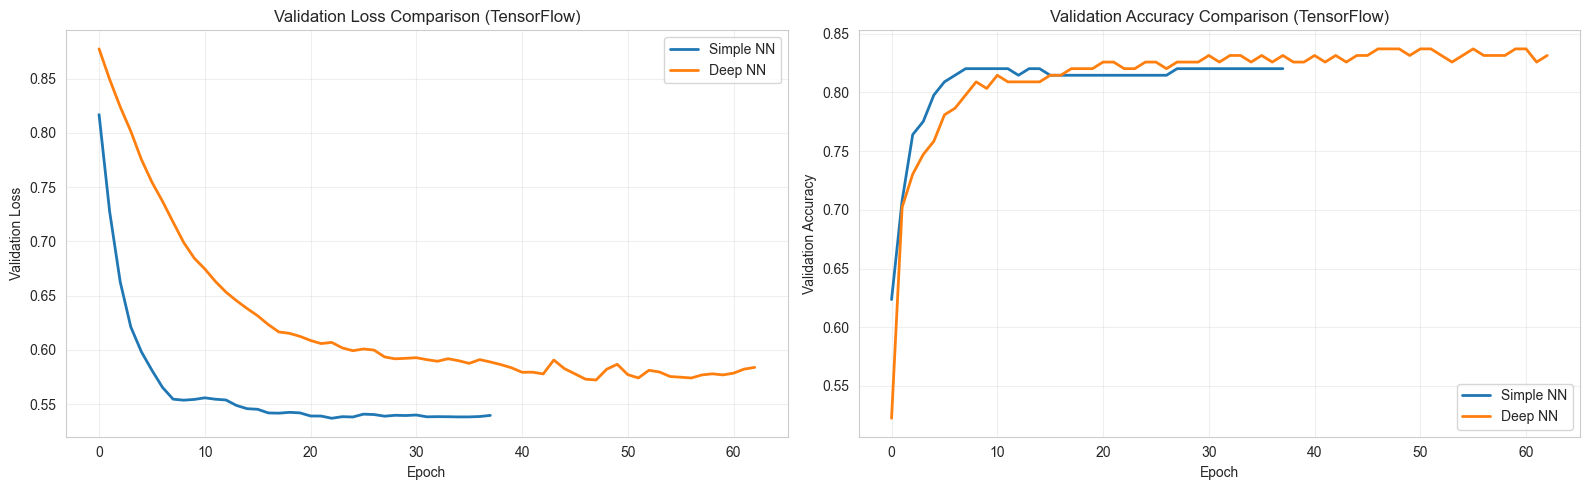

In [25]:
# Compare training histories
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss comparison
axes[0].plot(simple_history.history['val_loss'], label='Simple NN', linewidth=2)
axes[0].plot(deep_history.history['val_loss'], label='Deep NN', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss Comparison (TensorFlow)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(simple_history.history['val_accuracy'], label='Simple NN', linewidth=2)
axes[1].plot(deep_history.history['val_accuracy'], label='Deep NN', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy Comparison (TensorFlow)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Save TensorFlow Models

In [26]:
# Create models directory
models_dir = Path('../models/tensorflow')
models_dir.mkdir(parents=True, exist_ok=True)

# Save models in Keras format (.keras)
simple_model.save(models_dir / 'simple_nn.keras')
deep_model.save(models_dir / 'deep_nn.keras')

# Also save in H5 format for compatibility
simple_model.save(models_dir / 'simple_nn.h5')
deep_model.save(models_dir / 'deep_nn.h5')

# Save scaler
with open(models_dir / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("TensorFlow models saved:")
print(f"  - {models_dir / 'simple_nn.keras'}")
print(f"  - {models_dir / 'deep_nn.keras'}")
print(f"  - {models_dir / 'simple_nn.h5'}")
print(f"  - {models_dir / 'deep_nn.h5'}")
print(f"  - {models_dir / 'scaler.pkl'}")

TensorFlow models saved:
  - ..\models\tensorflow\simple_nn.keras
  - ..\models\tensorflow\deep_nn.keras
  - ..\models\tensorflow\simple_nn.h5
  - ..\models\tensorflow\deep_nn.h5
  - ..\models\tensorflow\scaler.pkl


In [27]:
# Save training histories
import json

# Convert history to dict and save
simple_history_dict = {
    'loss': simple_history.history['loss'],
    'val_loss': simple_history.history['val_loss'],
    'accuracy': simple_history.history['accuracy'],
    'val_accuracy': simple_history.history['val_accuracy']
}

deep_history_dict = {
    'loss': deep_history.history['loss'],
    'val_loss': deep_history.history['val_loss'],
    'accuracy': deep_history.history['accuracy'],
    'val_accuracy': deep_history.history['val_accuracy']
}

with open(models_dir / 'simple_nn_history.json', 'w') as f:
    json.dump(simple_history_dict, f)

with open(models_dir / 'deep_nn_history.json', 'w') as f:
    json.dump(deep_history_dict, f)

print("\nTraining histories saved.")


Training histories saved.
